In [26]:
import pandas as pd
import ta as ta

df = pd.read_csv("processed_data.csv")

df.sort_values("date", inplace=True, ascending=True)

df["target"] = df["pltr_close"].shift(-1) - df["pltr_open"].shift(-1)
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df = ta.add_all_ta_features(df, open="pltr_open", high="pltr_high", low="pltr_low", close="pltr_close", volume="pltr_volume")
df["oil_cci"] = ta.trend.cci(df["oil_high"], df["oil_low"], df["oil_close"], window=10)
df["oil_rsi"] = ta.momentum.rsi(df["oil_close"], window=14)
df["lmt_rsi"] = ta.momentum.rsi(df["lmt_close"], window=14)
df["lmt_MACD"] = ta.trend.macd_diff(df["lmt_close"], window_slow=26, window_fast=12, window_sign=9)
df["lmt_MACD_signal"] = ta.trend.macd_signal(df["lmt_close"], window_slow=26, window_fast=12, window_sign=9)
df["SPY_rsi"] = ta.momentum.rsi(df["spy_close"], window=14)
df["RTX_CMF"] = ta.volume.chaikin_money_flow(df["rtx_high"], df["rtx_low"], df["rtx_close"], df["rtx_volume"], window=20)
df["RTX_RSI"] = ta.momentum.rsi(df["rtx_close"], window=14)
df["QQQ_awesome_oscillator"] = ta.momentum.awesome_oscillator(df["qqq_high"], df["qqq_low"], window1=5, window2=34)
df["QQQ_rsi"] = ta.momentum.rsi(df["qqq_close"], window=14)
#df["noc_EMA"] = ta.trend.ema_indicator(df["noc_close"], window=12)
df.drop(columns=["trend_psar_up", "trend_psar_down", "trend_psar_up_indicator", "trend_psar_down_indicator"], inplace=True)
#df.dropna(inplace=True)
df.to_csv("technical_indicators_data.csv", index=False)


In [24]:
df = pd.read_csv("technical_indicators_data.csv")
df = df.dropna(inplace=False)
df.to_csv("final_data.csv", index=False)

(1128, 190)
(878, 190) (878,)
(250, 190) (250,)
              precision    recall  f1-score   support

           0       0.42      0.15      0.22       116
           1       0.53      0.83      0.65       134

    accuracy                           0.51       250
   macro avg       0.48      0.49      0.43       250
weighted avg       0.48      0.51      0.45       250

[[ 17  99]
 [ 23 111]]


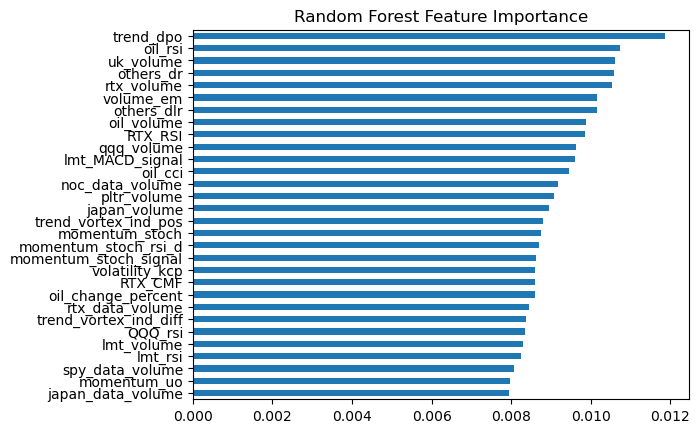

Accuracy: 0.5120


In [36]:
df.dropna(inplace=True)
normalized_df = df.copy()
for column in df.columns:
    if column not in ["date", "target"]:
        normalized_df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
normalized_df.to_csv("normalized_data.csv", index=False)

X = normalized_df.drop(columns=["target", "date"])
print(X.shape)
y = normalized_df["target"]
x_train = X[:-250]
y_train = y[:-250]
x_test = X[-250:]
y_test = y[-250:]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=80, min_samples_split=10, min_samples_leaf=4)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# Plot top N
feat_imp.head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

accuracy = (y_test == y_pred).mean()
print(f"Accuracy: {accuracy:.4f}")

In [44]:
#lasso regression
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.00001, max_iter=50000 )
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)
y_pred_lasso_binary = (y_pred_lasso > 0.5).astype(int)

accuracy = (y_test == y_pred_lasso_binary).mean()
print(f"Lasso Regression Accuracy: {accuracy:.4f}")



Lasso Regression Accuracy: 0.5320


c:\Users\liamk\miniconda3\envs\csci1470\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.732e-01, tolerance: 2.195e-02
  model = cd_fast.enet_coordinate_descent(


In [50]:
#XGBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=200, max_depth=80, min_samples_split=5, min_samples_leaf=2, learning_rate=0.01)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy = (y_test == y_pred_xgb).mean()
print(f"XGBoost Accuracy: {accuracy:.4f}")

###GRID SEARCH
#from sklearn.model_selection import GridSearchCV
#param_grid = {
#    'n_estimators': [100, 200, 300, 500],
#    'max_depth': [20, 80, 150],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 4]
#}
#grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
#grid_search.fit(x_train, y_train)
#print(f"Best parameters: {grid_search.best_params_}")
#print(f"Best cross-validation score: {grid_search.best_score_}")



c:\Users\liamk\miniconda3\envs\csci1470\lib\site-packages\xgboost\core.py:158: UserWarning: [11:11:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.5560
